## 1) Текстовое описание набора данных

В качестве набора данных мы будем использовать набор данных по микоризным грибам тропических лесов - https://www.kaggle.com/datasets/willianoliveiragibin/fungal-mycorrhizal-tropical

Эта задача является актуальной для экологических исследований, изучения взаимосвязи тропических растений с микоризными грибами (арбускулярная AM и эктомикориза ECM), а также для анализа морфологических характеристик корневой системы деревьев в тропических экосистемах.

Датасет представлен одним файлом:
- fungal_mycorrhizal_tropical new.csv - содержит данные по 66 видам деревьев из 40 родов с морфометрией корней и типом микоризы

Каждый файл содержит следующие колонки:
- Sample - номер образца
- Gen_sp（属_种） - род и вид растения (40 родов, 66 видов)
- 菌根类型 - тип микоризы: AM (арбускулярная микориза) или ECM (эктомикориза). Целевой признак для классификации.
- dbh(cm) - диаметр ствола на высоте груди в см
- height(m) - высота дерева в м
- TotalRootFreshMass(g) - общая масса свежих корней в г
- RootTipsFreshMass(g) - масса свежих корневых окончаний в г
- RemainingRootFreshMass(g) - масса оставшейся части свежих корней в г
- RemainingRootDryMass(g) - сухая масса оставшейся части корней в г
- RootTipsDryMass(g) - сухая масса корневых окончаний в г
- TotalRootDryMass(g) - общая сухая масса корней в г
- RootTipMassFraction(%) - массовая доля корневых окончаний в %
- RootDryMatterContent(mg/g) - содержание сухого вещества в корнях в мг/г
- RootWaterContent(%) - содержание воды в корнях в %
- RootLength(cm) - длина корней в см
- SpecificRootLength(cm/g) - удельная длина корней в см/г
- RootArea(cm²) - площадь поверхности корней в см²
- SpecifcRootArea(cm²/g) - удельная площадь корней в см²/г
- RootAvgDiam(mm) - средний диаметр корней в мм
- RootLenPerVol(cm/m³) - плотность длины корней в см/м³
- RootVolume(cm³) - объём корней в см³
- RootTissueDensity(g/cm³) - плотность корневой ткани в г/см³
- NRootTips - количество корневых окончаний
- branchiness(tips/length) - ветвистость (отношение числа окончаний к длине)
- SRTipAbund(tips/g) - удельная численность корневых окончаний на г
- Forks - количество точек разветвления корней
- Crossings - количество пересечений корней

## 2) Подготовка данных к анализу

Подготовка включает: импорт библиотек, загрузку данных с учётом формата (десятичный разделитель — запятая), проверку пропусков, приведение типов данных и итоговый обзор.

### Импорт библиотек

In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline 
sns.set(style="ticks")

### Загрузка данных

Файл CSV использует запятую как разделитель колонок и как десятичный разделитель (европейский формат). Указываем параметр `decimal=','` для корректного чтения числовых значений.

In [2]:
data = pd.read_csv('fungal_mycorrhizal_tropical new.csv', sep=',', decimal=',')
data.head()

,Sample,Gen_sp（属_种）(40属，66种）,菌根类型,dbh(cm)（胸径）,height(m)（树高）,TotalRootFreshMass(g)（总根鲜质量）,RootTipsFreshMass(g)（根尖鲜质量）,RemainingRootFreshMass(g)（剩余根鲜质量）,RemainingRootDryMass(g)（剩余根干质量）,RootTipsDryMass(g)（根尖干质量）,...,SpecifcRootArea(cm²/g)（比根面积）,RootAvgDiam(mm)（根平均直径）,RootLenPerVol(cm/m³)（根长密度）,RootVolume(cm³)（根体积）,RootTissueDensity(g/cm³)（根组织密度）,NRootTips（根尖数）,branchiness(tips/length)（分枝性）,SRTipAbund(tips/g)（比根尖丰度）,Forks（交叉点）,Crossings（交叉数）
0,1,Acer laurinum,AM,2.880000,3.4,0.602600,0.266200,0.336400,0.108733,0.075947,...,231.163353,0.628927,199.892733,0.627933,0.317865,453.466667,2.351315,2668.894276,589.933333,21.133333
1,2,Acronychia pedunculata,AM,10.600000,8.9,0.729889,0.248333,0.481556,0.128333,0.070849,...,199.072131,0.676133,183.714522,0.583444,0.339508,314.555556,1.986163,1937.663628,533.333333,33.111111
2,3,Actinodaphne henryi,AM,3.433333,5.0,0.540667,0.290111,0.250556,0.089111,0.082769,...,168.654855,0.784567,117.603700,0.529667,0.329182,172.000000,1.495052,1114.004345,222.666667,7.333333
3,4,Alchornea tiliifolia,AM,2.400000,3.9,0.495333,0.161889,0.333444,0.093000,0.046187,...,227.150611,0.655533,137.960478,0.448556,0.322378,444.333333,3.157828,3610.289217,455.333333,20.444444
4,5,Antiaris toxicaria,AM,3.300000,5.0,0.766667,0.166000,0.600667,0.165000,0.047360,...,142.866736,0.720533,103.767900,0.447000,0.439211,354.000000,3.603314,2557.800809,262.000000,9.000000


### Приведение названий колонок к нормальному виду

Убираем китайские символы, скобки и спецсимволы. Приводим к snake_case.

In [3]:
# Сопоставление старых названий новым (нормализованным)
column_rename = {
    data.columns[0]: 'sample',
    data.columns[1]: 'gen_sp',
    data.columns[2]: 'mycorrhizal_type',  # целевой признак
    data.columns[3]: 'dbh_cm',
    data.columns[4]: 'height_m',
    data.columns[5]: 'total_root_fresh_mass_g',
    data.columns[6]: 'root_tips_fresh_mass_g',
    data.columns[7]: 'remaining_root_fresh_mass_g',
    data.columns[8]: 'remaining_root_dry_mass_g',
    data.columns[9]: 'root_tips_dry_mass_g',
    data.columns[10]: 'total_root_dry_mass_g',
    data.columns[11]: 'root_tip_mass_fraction_pct',
    data.columns[12]: 'root_dry_matter_content_mg_g',
    data.columns[13]: 'root_water_content_pct',
    data.columns[14]: 'root_length_cm',
    data.columns[15]: 'specific_root_length_cm_g',
    data.columns[16]: 'root_area_cm2',
    data.columns[17]: 'specific_root_area_cm2_g',
    data.columns[18]: 'root_avg_diam_mm',
    data.columns[19]: 'root_len_per_vol_cm_m3',
    data.columns[20]: 'root_volume_cm3',
    data.columns[21]: 'root_tissue_density_g_cm3',
    data.columns[22]: 'n_root_tips',
    data.columns[23]: 'branchiness',
    data.columns[24]: 'sr_tip_abund',
    data.columns[25]: 'forks',
    data.columns[26]: 'crossings',
}
data = data.rename(columns=column_rename)
print('Новые названия колонок:', list(data.columns))

Новые названия колонок: ['sample', 'gen_sp', 'mycorrhizal_type', 'dbh_cm', 'height_m', 'total_root_fresh_mass_g', 'root_tips_fresh_mass_g', 'remaining_root_fresh_mass_g', 'remaining_root_dry_mass_g', 'root_tips_dry_mass_g', 'total_root_dry_mass_g', 'root_tip_mass_fraction_pct', 'root_dry_matter_content_mg_g', 'root_water_content_pct', 'root_length_cm', 'specific_root_length_cm_g', 'root_area_cm2', 'specific_root_area_cm2_g', 'root_avg_diam_mm', 'root_len_per_vol_cm_m3', 'root_volume_cm3', 'root_tissue_density_g_cm3', 'n_root_tips', 'branchiness', 'sr_tip_abund', 'forks', 'crossings']


In [4]:
# Размер датасета
print(f'Строк: {data.shape[0]}, колонок: {data.shape[1]}')
data.dtypes

Строк: 66, колонок: 27


sample                            int64
gen_sp                           object
mycorrhizal_type                 object
dbh_cm                          float64
height_m                        float64
total_root_fresh_mass_g         float64
root_tips_fresh_mass_g          float64
remaining_root_fresh_mass_g     float64
remaining_root_dry_mass_g       float64
root_tips_dry_mass_g            float64
total_root_dry_mass_g           float64
root_tip_mass_fraction_pct      float64
root_dry_matter_content_mg_g    float64
root_water_content_pct          float64
root_length_cm                  float64
specific_root_length_cm_g       float64
root_area_cm2                   float64
specific_root_area_cm2_g        float64
root_avg_diam_mm                float64
root_len_per_vol_cm_m3          float64
root_volume_cm3                 float64
root_tissue_density_g_cm3       float64
n_root_tips                     float64
branchiness                     float64
sr_tip_abund                    float64


### Проверка пропусков и аномалий

In [5]:
# Количество пропущенных значений по колонкам
print('Пропущенные значения:')
for col in data.columns:
    null_count = data[col].isnull().sum()
    if null_count > 0:
        print(f'  {col}: {null_count} ({null_count/data.shape[0]*100:.1f}%)')
    else:
        print(f'  {col}: 0')

Пропущенные значения:
  sample: 0
  gen_sp: 0
  mycorrhizal_type: 0
  dbh_cm: 1 (1.5%)
  height_m: 1 (1.5%)
  total_root_fresh_mass_g: 0
  root_tips_fresh_mass_g: 0
  remaining_root_fresh_mass_g: 0
  remaining_root_dry_mass_g: 0
  root_tips_dry_mass_g: 0
  total_root_dry_mass_g: 0
  root_tip_mass_fraction_pct: 0
  root_dry_matter_content_mg_g: 0
  root_water_content_pct: 0
  root_length_cm: 0
  specific_root_length_cm_g: 0
  root_area_cm2: 0
  specific_root_area_cm2_g: 0
  root_avg_diam_mm: 0
  root_len_per_vol_cm_m3: 0
  root_volume_cm3: 0
  root_tissue_density_g_cm3: 0
  n_root_tips: 0
  branchiness: 0
  sr_tip_abund: 0
  forks: 0
  crossings: 0


### Обработка пропусков и приведение типов

Для числовых колонок пропуски заполняем медианой. Для целевого признака (тип микоризы) строки с пропусками удаляем.

In [6]:
# Целевая колонка — тип микоризы
target_col = 'mycorrhizal_type'
numeric_cols = data.select_dtypes(include=[np.number]).columns.tolist()

# Удаляем строки с пропусками в целевом признаке
data_clean = data.dropna(subset=[target_col]).copy()

# Заполняем пропуски в числовых колонках медианой
for col in numeric_cols:
    if col in data_clean.columns and data_clean[col].isnull().any():
        data_clean[col] = data_clean[col].fillna(data_clean[col].median())

print(f'После обработки: {len(data_clean)} строк')
print(f'Осталось пропусков: {data_clean.isnull().sum().sum()}')

После обработки: 66 строк
Осталось пропусков: 0


### Итоговая структура подготовленных данных

In [7]:
# Распределение целевого признака (тип микоризы)
print('Распределение типов микоризы:')
print(data_clean[target_col].value_counts())

# Сводная статистика по числовым признакам
print('\nСводная статистика:')
data_clean.describe()

Распределение типов микоризы:
AM     54
ECM    12
Name: mycorrhizal_type, dtype: int64

Сводная статистика:


,sample,dbh_cm,height_m,total_root_fresh_mass_g,root_tips_fresh_mass_g,remaining_root_fresh_mass_g,remaining_root_dry_mass_g,root_tips_dry_mass_g,total_root_dry_mass_g,root_tip_mass_fraction_pct,...,specific_root_area_cm2_g,root_avg_diam_mm,root_len_per_vol_cm_m3,root_volume_cm3,root_tissue_density_g_cm3,n_root_tips,branchiness,sr_tip_abund,forks,crossings
count,66.000000,66.000000,66.000000,66.000000,66.000000,66.000000,66.000000,66.000000,66.000000,66.000000,...,66.000000,66.000000,66.000000,66.000000,66.000000,66.000000,66.000000,66.000000,66.000000,66.000000
mean,33.500000,4.520606,5.071641,0.678917,0.250227,0.428532,0.127451,0.071328,0.198779,34.898402,...,164.280641,0.818303,120.481202,0.559452,0.373840,294.965115,2.551542,2167.692813,334.466534,17.423906
std,19.196354,3.012297,1.792947,0.444865,0.198727,0.269450,0.066826,0.056726,0.112712,10.397654,...,54.265018,0.285591,62.180526,0.390978,0.076738,198.687117,0.898929,1685.112313,332.503846,24.673432
min,1.000000,1.500000,2.000000,0.220556,0.038667,0.150556,0.038111,0.011032,0.058082,13.923397,...,73.038787,0.416733,27.831633,0.158333,0.240520,71.000000,0.953983,208.504176,19.666667,0.166667
25%,17.250000,2.500000,3.945000,0.385382,0.126083,0.252083,0.078139,0.035972,0.126129,27.293254,...,130.254790,0.647033,79.371540,0.343611,0.320949,160.477778,1.925938,966.962375,102.875000,2.750000
50%,33.500000,3.400000,4.750000,0.551292,0.194367,0.345867,0.113639,0.055453,0.167984,34.232849,...,157.230937,0.758183,108.365417,0.456611,0.356960,240.333333,2.425494,1695.685225,231.000000,7.416667
75%,49.750000,5.116667,5.800000,0.787917,0.289417,0.535708,0.156083,0.082571,0.232150,41.899124,...,198.613846,0.924900,163.363700,0.669417,0.418628,366.375000,3.166182,2750.495280,426.000000,20.138889
max,66.000000,14.300000,9.100000,2.820000,1.114667,1.705333,0.339667,0.318014,0.657681,64.602224,...,323.078336,1.925863,382.031017,2.688000,0.620138,1210.333333,4.970317,8961.743999,1912.833333,131.333333


## 3) Визуальное исследование датасета

В этом разделе представлены графики для анализа распределений признаков, сравнения групп AM/ECM и корреляций между числовыми переменными.

### Распределение целевого признака (тип микоризы)

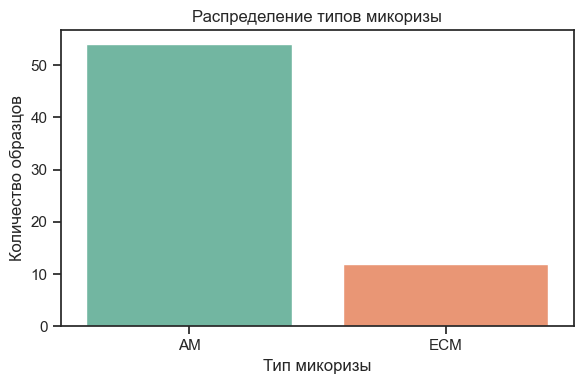

In [8]:
# Столбчатая диаграмма: количество образцов по типу микоризы (AM / ECM)
fig, ax = plt.subplots(figsize=(6, 4))
sns.countplot(data=data_clean, x=target_col, order=['AM', 'ECM'], palette='Set2')
ax.set_title('Распределение типов микоризы')
ax.set_xlabel('Тип микоризы')
ax.set_ylabel('Количество образцов')
plt.tight_layout()
plt.show()

### Распределения числовых признаков

Гистограммы выбранных признаков: размеры дерева (dbh, height), морфометрия корней (длина, площадь, количество окончаний).

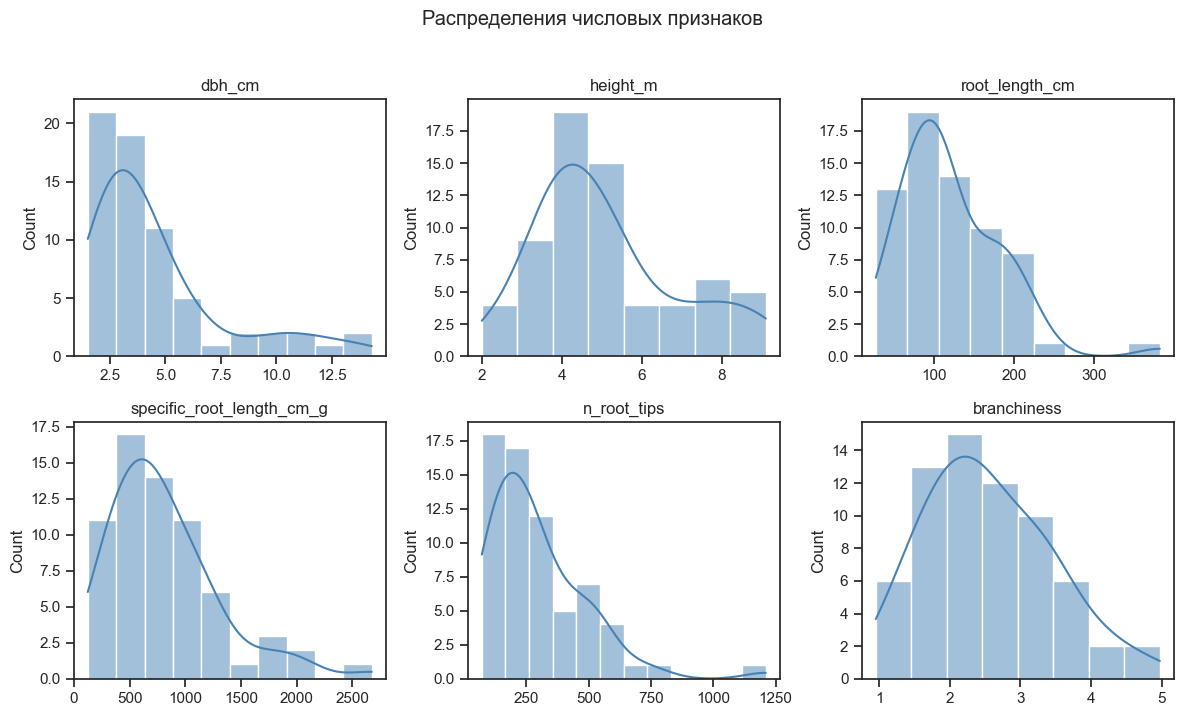

In [9]:
# Выбор числовых признаков для визуализации (без sample)
feat_cols = ['dbh_cm', 'height_m', 'root_length_cm', 'specific_root_length_cm_g', 'n_root_tips', 'branchiness']
fig, axes = plt.subplots(2, 3, figsize=(12, 7))
axes = axes.flatten()
for i, col in enumerate(feat_cols):
    sns.histplot(data_clean[col], kde=True, ax=axes[i], color='steelblue')
    axes[i].set_title(col)
    axes[i].set_xlabel('')
plt.suptitle('Распределения числовых признаков', y=1.02)
plt.tight_layout()
plt.show()

### Сравнение признаков по типу микоризы (ящики с усами)

Сравнение распределений ключевых признаков между группами AM и ECM помогает выявить различия в морфологии корней.

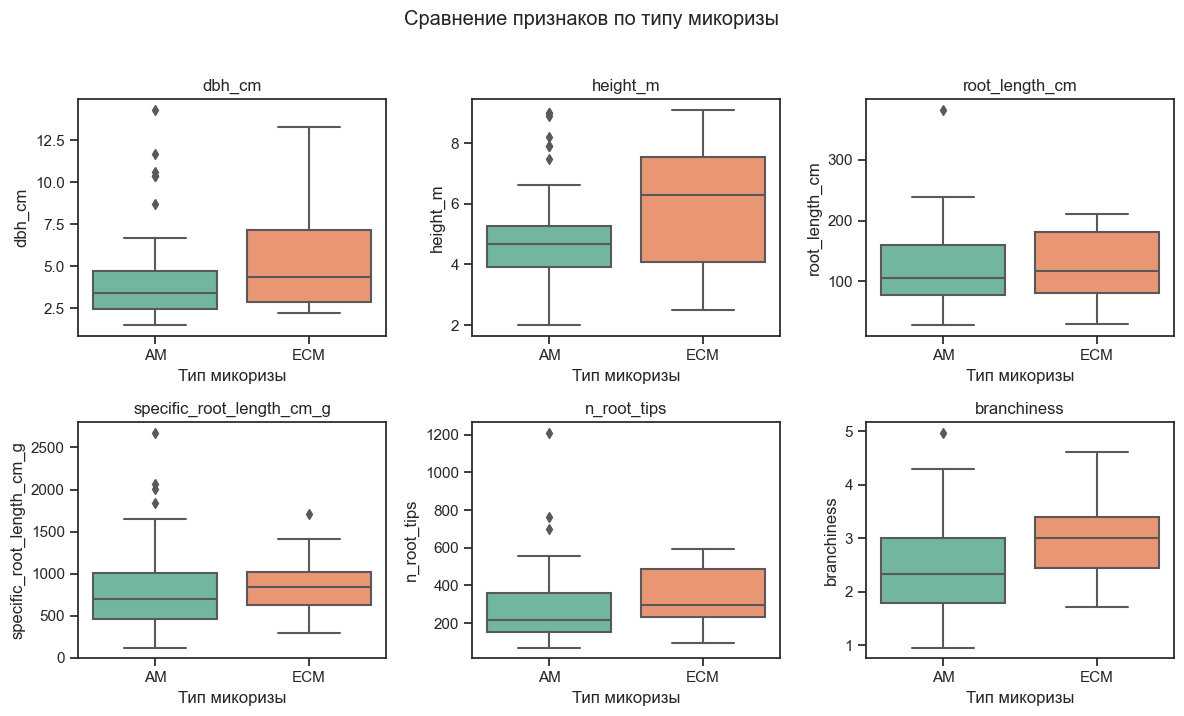

In [10]:
# Ящики с усами: выбранные признаки по типу микоризы
fig, axes = plt.subplots(2, 3, figsize=(12, 7))
axes = axes.flatten()
for i, col in enumerate(feat_cols):
    sns.boxplot(data=data_clean, x=target_col, y=col, order=['AM', 'ECM'], palette='Set2', ax=axes[i])
    axes[i].set_title(col)
    axes[i].set_xlabel('Тип микоризы')
plt.suptitle('Сравнение признаков по типу микоризы', y=1.02)
plt.tight_layout()
plt.show()

### Диаграмма рассеяния

Связь между двумя признаками с раскраской по типу микоризы (AM / ECM).

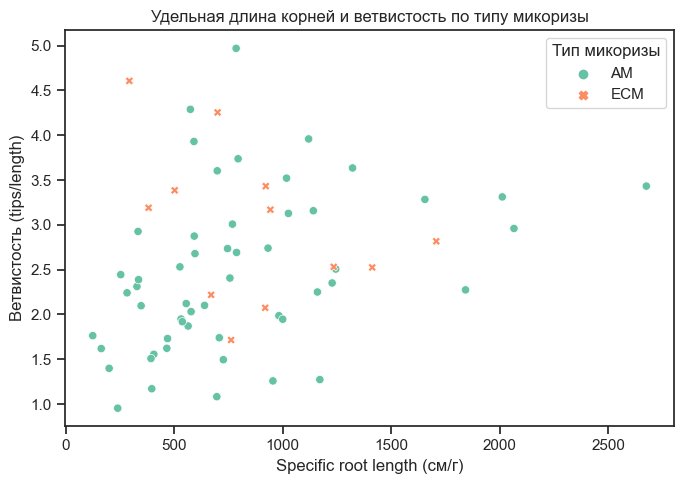

In [11]:
# Диаграмма рассеяния: удельная длина корней vs ветвистость, цвет — тип микоризы
fig, ax = plt.subplots(figsize=(7, 5))
sns.scatterplot(data=data_clean, x='specific_root_length_cm_g', y='branchiness', hue=target_col, style=target_col, palette='Set2')
ax.set_title('Удельная длина корней и ветвистость по типу микоризы')
ax.set_xlabel('Specific root length (см/г)')
ax.set_ylabel('Ветвистость (tips/length)')
plt.legend(title='Тип микоризы')
plt.tight_layout()
plt.show()

### Корреляция числовых признаков

Тепловая карта корреляционной матрицы (только числовые колонки, без идентификатора sample).

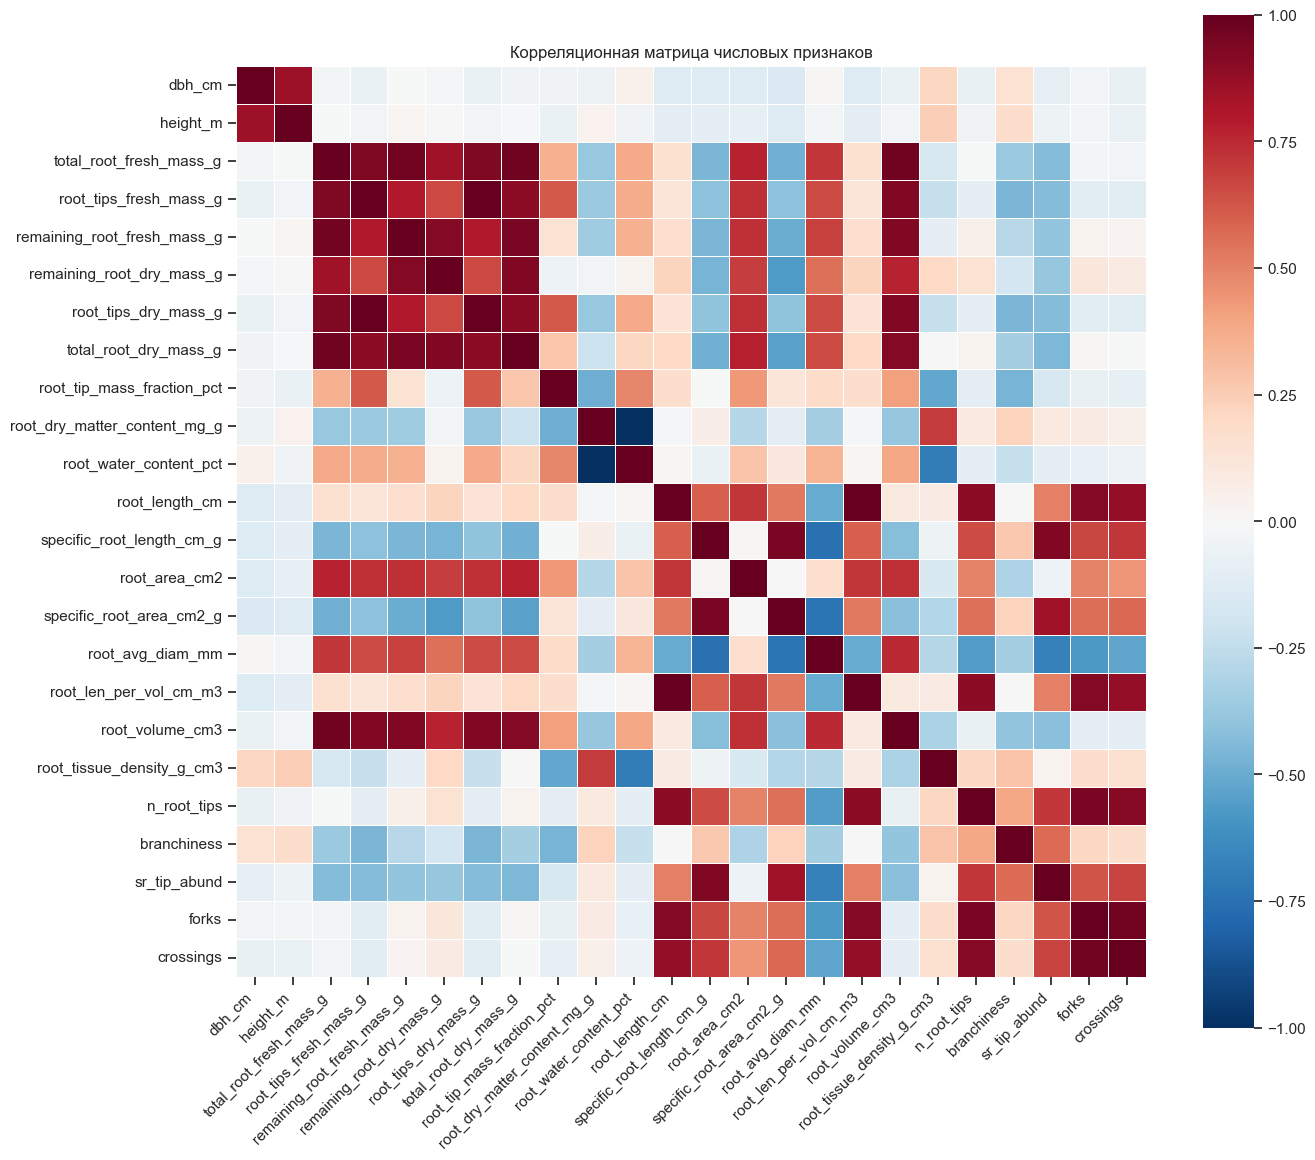

In [12]:
# Числовые колонки для корреляции (исключаем sample и нечисловые)
num_df = data_clean.select_dtypes(include=[np.number]).drop(columns=['sample'], errors='ignore')
corr = num_df.corr()
fig, ax = plt.subplots(figsize=(14, 12))
sns.heatmap(corr, annot=False, cmap='RdBu_r', center=0, square=True, linewidths=0.5, ax=ax)
ax.set_title('Корреляционная матрица числовых признаков')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [13]:
data['mycorrhizal_type'].unique()

array(['AM', 'ECM'], dtype=object)

## 4) Дополнительное визуальное исследование данных

Для более полного разведочного анализа добавим несколько типов графиков по образцу лабораторной работы: парные диаграммы, jointplot, violin plot и анализ связей признаков с целевой переменной. Так как датасет небольшой и классы несбалансированы, графики используются прежде всего для поиска визуальных закономерностей, а не для строгих статистических выводов.

### Парные диаграммы

Парные диаграммы позволяют одновременно оценить распределения признаков и связи между ними. Для читаемости выберем несколько наиболее интерпретируемых признаков, связанных с размерами дерева и морфологией корней.

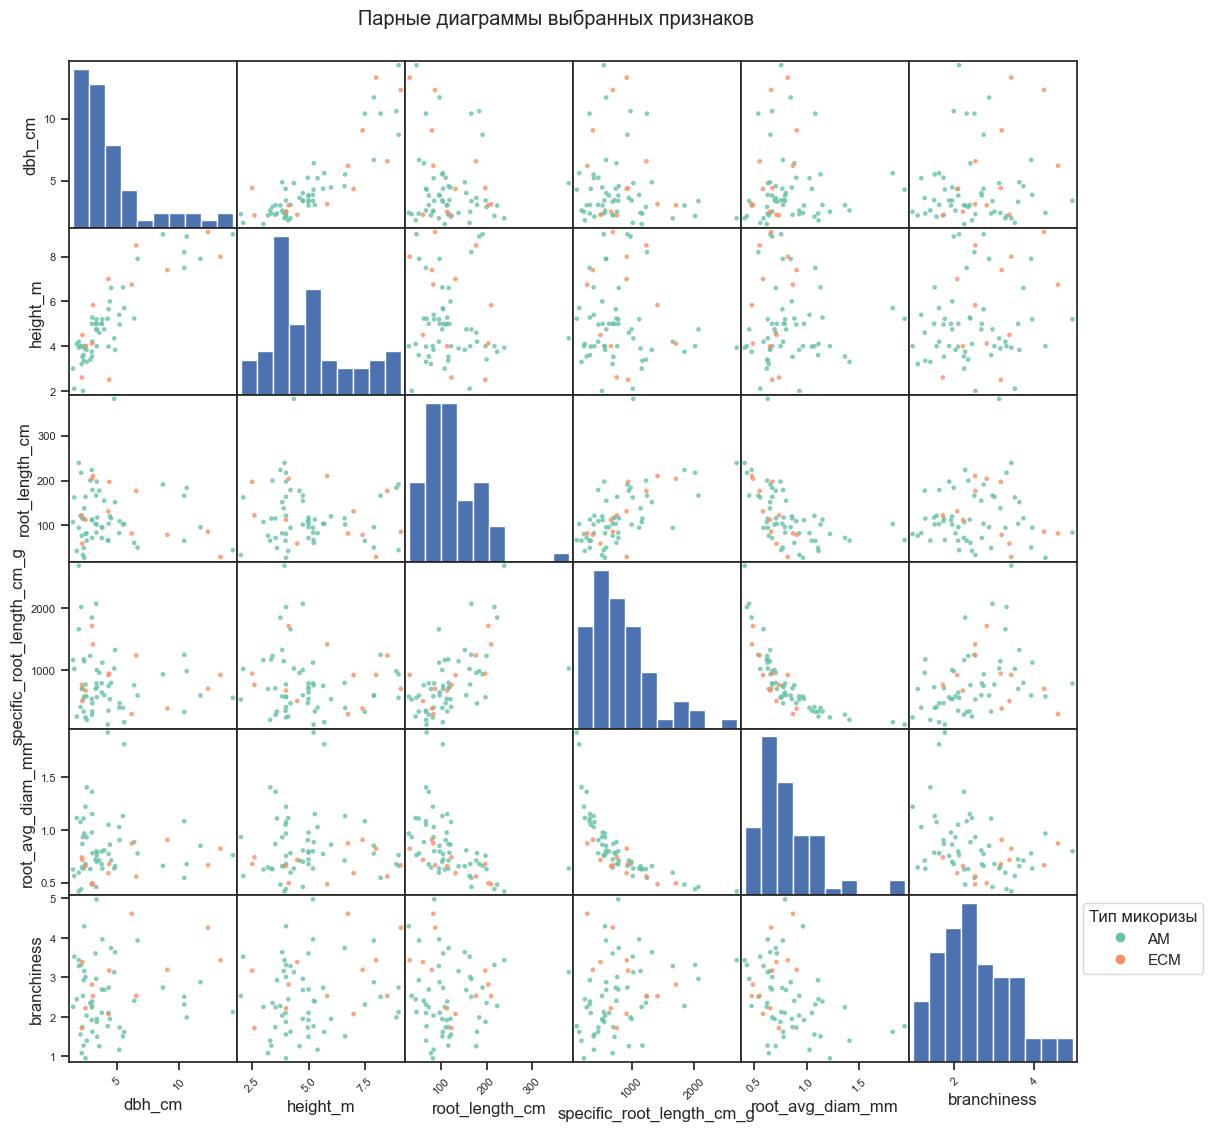

In [18]:
# Парные диаграммы для выбранных признаков с раскраской по типу микоризы
# Используем scatter_matrix вместо sns.pairplot, чтобы избежать ошибки совместимости
# старых версий seaborn с текущими версиями matplotlib.
from pandas.plotting import scatter_matrix

pair_features = [
    'dbh_cm',
    'height_m',
    'root_length_cm',
    'specific_root_length_cm_g',
    'root_avg_diam_mm',
    'branchiness'
]

class_colors = data_clean[target_col].map({'AM': '#66c2a5', 'ECM': '#fc8d62'})

axes = scatter_matrix(
    data_clean[pair_features],
    figsize=(13, 13),
    diagonal='hist',
    color=class_colors,
    alpha=0.8,
    s=45
)

for ax in axes.flatten():
    ax.tick_params(axis='x', labelrotation=45)
    ax.tick_params(axis='y', labelrotation=0)

handles = [
    plt.Line2D([0], [0], marker='o', color='w', label='AM', markerfacecolor='#66c2a5', markersize=8),
    plt.Line2D([0], [0], marker='o', color='w', label='ECM', markerfacecolor='#fc8d62', markersize=8)
]
plt.legend(handles=handles, title='Тип микоризы', loc='upper right', bbox_to_anchor=(1.8, 1.0))
plt.suptitle('Парные диаграммы выбранных признаков', y=0.92)
plt.show()

### Jointplot

Проверим связь между длиной корней и площадью поверхности корней. Эти признаки должны быть положительно связаны, так как при увеличении общей длины корневой системы обычно растёт и площадь поверхности.

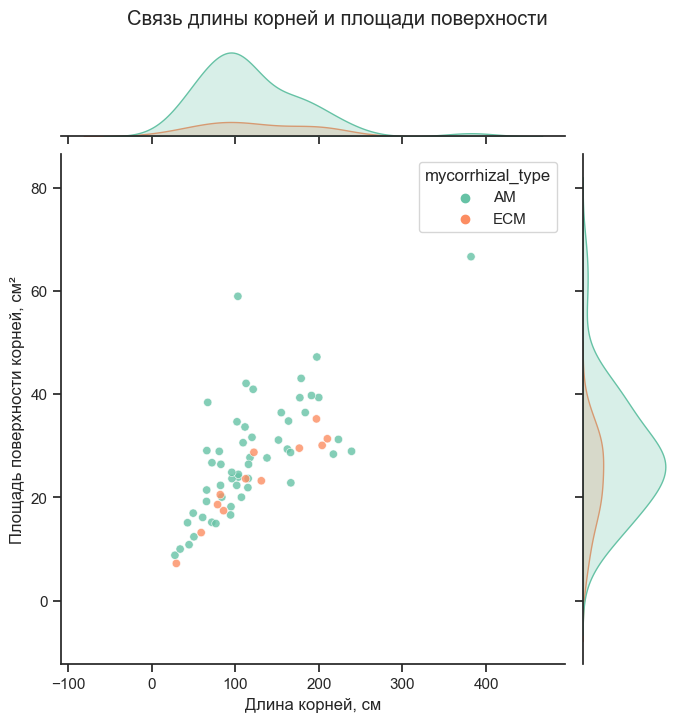

In [19]:
# Совместное распределение длины и площади корней
joint = sns.jointplot(
    data=data_clean,
    x='root_length_cm',
    y='root_area_cm2',
    hue=target_col,
    palette='Set2',
    height=7,
    alpha=0.8
)
joint.fig.suptitle('Связь длины корней и площади поверхности', y=1.03)
joint.set_axis_labels('Длина корней, см', 'Площадь поверхности корней, см²')
plt.show()

### Violin plot

Диаграммы violin plot показывают не только медиану и разброс, но и форму распределения признака внутри каждого класса. Это полезно для сравнения групп AM и ECM при небольшом числе наблюдений.

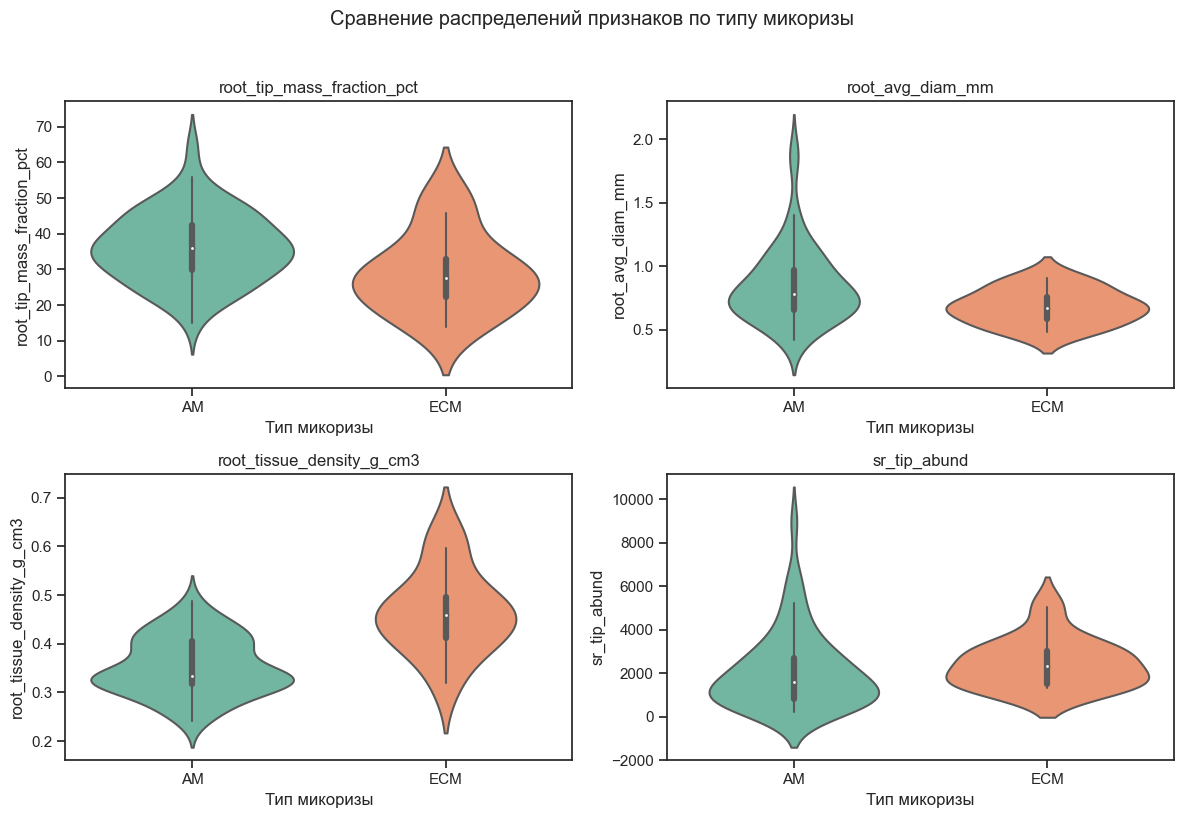

In [20]:
# Violin plot для признаков, связанных со структурой и плотностью корней
violin_cols = [
    'root_tip_mass_fraction_pct',
    'root_avg_diam_mm',
    'root_tissue_density_g_cm3',
    'sr_tip_abund'
]

fig, axes = plt.subplots(2, 2, figsize=(12, 8))
axes = axes.flatten()

for i, col in enumerate(violin_cols):
    sns.violinplot(
        data=data_clean,
        x=target_col,
        y=col,
        order=['AM', 'ECM'],
        palette='Set2',
        inner='box',
        ax=axes[i]
    )
    axes[i].set_title(col)
    axes[i].set_xlabel('Тип микоризы')

plt.suptitle('Сравнение распределений признаков по типу микоризы', y=1.02)
plt.tight_layout()
plt.show()

## 5) Информация о корреляции признаков

Для анализа связи признаков с целевой переменной закодируем тип микоризы численно: `AM = 0`, `ECM = 1`. После этого можно оценить, какие числовые признаки сильнее всего связаны с переходом от AM к ECM. Важно помнить, что корреляция не означает причинно-следственную связь.

Корреляция числовых признаков с типом микоризы (AM=0, ECM=1):
root_tissue_density_g_cm3       0.564576
root_water_content_pct         -0.498143
root_dry_matter_content_mg_g    0.498143
root_tip_mass_fraction_pct     -0.269881
branchiness                     0.233447
root_volume_cm3                -0.229929
root_avg_diam_mm               -0.225951
root_tips_dry_mass_g           -0.213200
root_tips_fresh_mass_g         -0.210987
height_m                        0.208497
total_root_fresh_mass_g        -0.196810
dbh_cm                          0.196670
remaining_root_fresh_mass_g    -0.169047
root_area_cm2                  -0.167400
n_root_tips                     0.118861
total_root_dry_mass_g          -0.114889
forks                           0.102883
sr_tip_abund                    0.078987
crossings                       0.078224
specific_root_area_cm2_g       -0.068233
specific_root_length_cm_g       0.057661
root_len_per_vol_cm_m3          0.027868
root_length_cm                  0.02

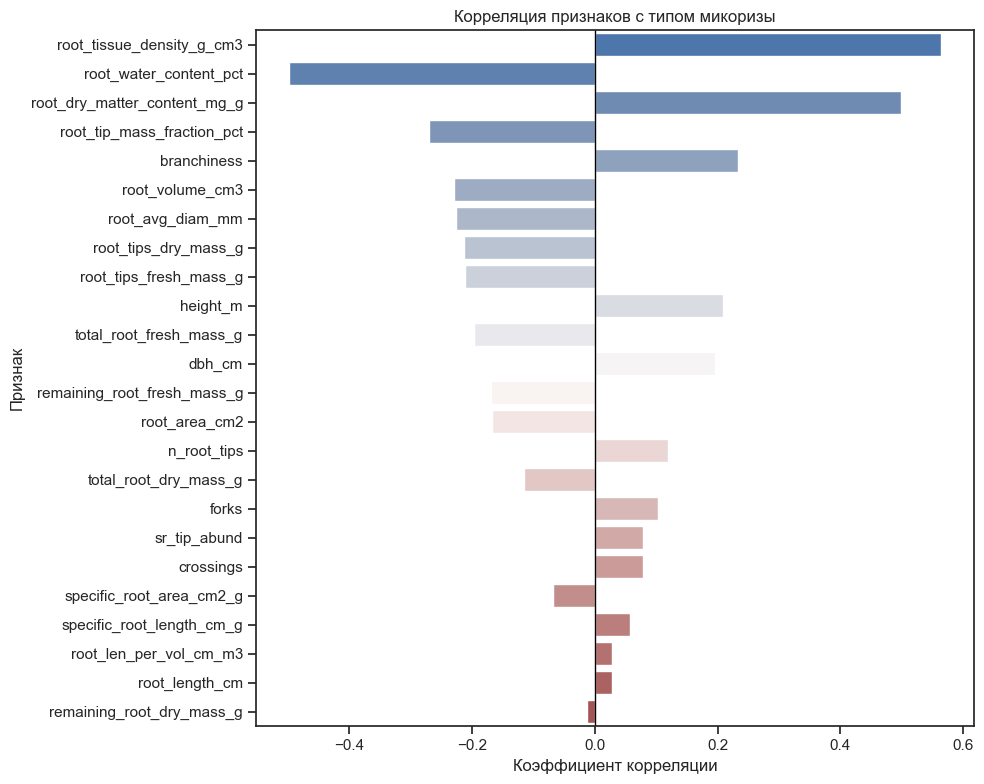

In [15]:
# Кодирование целевого признака для корреляционного анализа
analysis_df = data_clean.copy()
analysis_df['mycorrhizal_type_encoded'] = analysis_df[target_col].map({'AM': 0, 'ECM': 1})

corr_with_target = (
    analysis_df
    .select_dtypes(include=[np.number])
    .drop(columns=['sample'], errors='ignore')
    .corr()['mycorrhizal_type_encoded']
    .drop('mycorrhizal_type_encoded')
    .sort_values(key=lambda x: x.abs(), ascending=False)
)

print('Корреляция числовых признаков с типом микоризы (AM=0, ECM=1):')
print(corr_with_target)

fig, ax = plt.subplots(figsize=(10, 8))
sns.barplot(
    x=corr_with_target.values,
    y=corr_with_target.index,
    palette='vlag',
    ax=ax
)
ax.axvline(0, color='black', linewidth=1)
ax.set_title('Корреляция признаков с типом микоризы')
ax.set_xlabel('Коэффициент корреляции')
ax.set_ylabel('Признак')
plt.tight_layout()
plt.show()

### Наиболее сильные взаимосвязи между числовыми признаками

В морфометрических данных часть признаков рассчитывается на основе других показателей, поэтому между ними ожидаются сильные корреляции. Найдём пары признаков с наибольшей абсолютной корреляцией.

In [16]:
# Поиск наиболее коррелирующих пар числовых признаков
numeric_for_corr = data_clean.select_dtypes(include=[np.number]).drop(columns=['sample'], errors='ignore')
corr_matrix = numeric_for_corr.corr().abs()

# Оставляем только верхний треугольник матрицы, чтобы не дублировать пары
upper_mask = np.triu(np.ones(corr_matrix.shape), k=1).astype(bool)
upper_corr = corr_matrix.where(upper_mask)

top_corr_pairs = (
    upper_corr
    .stack()
    .sort_values(ascending=False)
    .head(15)
    .reset_index()
)
top_corr_pairs.columns = ['Признак 1', 'Признак 2', 'Абсолютная корреляция']

top_corr_pairs

,Признак 1,Признак 2,Абсолютная корреляция
0,root_length_cm,root_len_per_vol_cm_m3,1.000000
1,root_dry_matter_content_mg_g,root_water_content_pct,1.000000
2,root_tips_fresh_mass_g,root_tips_dry_mass_g,0.999961
3,total_root_fresh_mass_g,total_root_dry_mass_g,0.973271
4,total_root_fresh_mass_g,root_volume_cm3,0.970322
5,total_root_fresh_mass_g,remaining_root_fresh_mass_g,0.963821
6,forks,crossings,0.963389
7,n_root_tips,forks,0.946521
8,remaining_root_fresh_mass_g,total_root_dry_mass_g,0.946103
9,specific_root_length_cm_g,specific_root_area_cm2_g,0.945737


## 6) Выводы

В работе был проведён разведочный анализ данных о микоризных грибах тропических лесов. Датасет содержит 66 наблюдений и 27 исходных колонок: идентификатор образца, название вида растения, тип микоризы и числовые морфометрические признаки корневой системы.

Основные результаты анализа:

- Целевой признак `mycorrhizal_type` является бинарным и содержит два класса: `AM` и `ECM`.
- Распределение классов несбалансировано: образцов `AM` заметно больше, чем `ECM`.
- В данных обнаружено мало пропусков: по одному пропуску в признаках `dbh_cm` и `height_m`; они были заполнены медианными значениями.
- Большинство признаков являются числовыми, что позволяет применять статистическое описание, корреляционный анализ и стандартные методы визуализации.
- Между рядом морфометрических признаков наблюдаются сильные связи, что ожидаемо, так как часть показателей описывает близкие свойства корневой системы или рассчитывается на основе связанных величин.
- Визуальное сравнение групп AM и ECM показывает, что некоторые признаки могут отличаться между типами микоризы, однако из-за малого размера выборки и дисбаланса классов эти различия следует интерпретировать осторожно.

Подготовленный датасет можно использовать для дальнейшей задачи классификации типа микоризы. При построении модели важно исключить идентификатор `sample`, учитывать дисбаланс классов и использовать стратифицированное разбиение или кросс-валидацию.